In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

In [2]:
df = pd.read_csv('makerere_Cafeteria_synthetic.csv')

currency_cols = ['Price_UGX','Revenue_UGX','Ingredient_Cost_UGX',
                 'Waste_Cost_UGX','Gross_Profit_UGX']
for col in currency_cols:
    df[col] = df[col].astype(str).str.replace(',','').astype(float)

print(f"✅ Loaded {len(df):,} rows")

✅ Loaded 58,800 rows


In [3]:
data = pd.DataFrame()

# Categorical (already discrete)
data['Is_Weekend']       = df['Is_Weekend'].map({True:'Weekend', False:'Weekday'})
data['Academic_Period']  = df['Academic_Period'].apply(
    lambda x: 'Teaching' if 'Teaching' in str(x)
              else ('Exam' if 'Exam' in str(x) else 'Break'))
data['Meal_Type']        = df['Meal'].apply(
    lambda x: 'Premium' if x == 'Rice & Chicken'
              else ('Budget' if x in ['Posho & Beans','Rolex'] else 'Standard'))

# Discretise continuous → Low / Medium / High
def discretise(series, labels=['Low','Medium','High']):
    return pd.cut(series, bins=3, labels=labels)

data['Demand']       = discretise(df['Portions_Sold'])
data['Waste_Level']  = discretise(df['Waste_Pct'])
data['Revenue_Level']= discretise(df['Revenue_UGX'])
data['Cost_Level']   = discretise(df['Ingredient_Cost_UGX'])
data['Profit_Level'] = discretise(df['Gross_Profit_UGX'])

# Drop any NaN rows from binning
data = data.dropna()
print(f"✅ After discretisation: {len(data):,} rows, 8 variables")
print(f"\nVariable value counts:")
for col in data.columns:
    print(f"  {col}: {data[col].unique().tolist()}")


✅ After discretisation: 58,800 rows, 8 variables

Variable value counts:
  Is_Weekend: ['Weekday', 'Weekend']
  Academic_Period: ['Teaching', 'Exam', 'Break']
  Meal_Type: ['Budget', 'Standard', 'Premium']
  Demand: ['Medium', 'Low', 'High']
  Waste_Level: ['Low', 'High', 'Medium']
  Revenue_Level: ['Medium', 'Low', 'High']
  Cost_Level: ['Low', 'Medium', 'High']
  Profit_Level: ['Medium', 'Low', 'High']


In [4]:
edges = [
    ('Is_Weekend',      'Demand'),
    ('Is_Weekend',      'Waste_Level'),
    ('Academic_Period', 'Demand'),
    ('Meal_Type',       'Revenue_Level'),
    ('Meal_Type',       'Cost_Level'),
    ('Demand',          'Revenue_Level'),
    ('Revenue_Level',   'Profit_Level'),
    ('Cost_Level',      'Profit_Level'),
    ('Waste_Level',     'Profit_Level'),
]

G = nx.DiGraph()
G.add_edges_from(edges)
nodes = list(G.nodes())
print(f"\n✅ DAG structure: {len(nodes)} nodes, {len(edges)} edges")
print(f"   Nodes: {nodes}")


✅ DAG structure: 8 nodes, 9 edges
   Nodes: ['Is_Weekend', 'Demand', 'Waste_Level', 'Academic_Period', 'Meal_Type', 'Revenue_Level', 'Cost_Level', 'Profit_Level']


In [5]:
def get_parents(G, node):
    return list(G.predecessors(node))

def learn_cpt(data, node, parents, alpha=1.0):
    """
    Learn CPT using Maximum Likelihood Estimation with
    Laplace smoothing (alpha) to handle zero counts.
    Returns a dict: {parent_combo: {value: probability}}
    """
    values = sorted(data[node].unique())
    cpt = {}
    if not parents:
        counts = data[node].value_counts()
        total  = counts.sum() + alpha * len(values)
        cpt['marginal'] = {v: (counts.get(v, 0) + alpha) / total for v in values}
    else:
        grouped = data.groupby(parents + [node]).size().reset_index(name='count')
        parent_groups = data.groupby(parents).size().reset_index(name='total')
        for _, prow in parent_groups.iterrows():
            key = tuple(prow[p] for p in parents)
            mask = grouped[parents].apply(
                lambda row: tuple(row) == key, axis=1)
            sub = grouped[mask]
            total = prow['total'] + alpha * len(values)
            cpt[key] = {}
            for v in values:
                v_count = sub[sub[node] == v]['count'].sum()
                cpt[key][v] = (v_count + alpha) / total
    return cpt, values

print("\n📊 Learning CPTs...")
cpts   = {}
valmap = {}
for node in nodes:
    parents = get_parents(G, node)
    cpt, vals = learn_cpt(data, node, parents)
    cpts[node]   = cpt
    valmap[node] = vals
    print(f"   ✅ {node} | parents={parents} | values={vals}")


📊 Learning CPTs...
   ✅ Is_Weekend | parents=[] | values=['Weekday', 'Weekend']
   ✅ Demand | parents=['Is_Weekend', 'Academic_Period'] | values=['High', 'Low', 'Medium']
   ✅ Waste_Level | parents=['Is_Weekend'] | values=['High', 'Low', 'Medium']
   ✅ Academic_Period | parents=[] | values=['Break', 'Exam', 'Teaching']
   ✅ Meal_Type | parents=[] | values=['Budget', 'Premium', 'Standard']
   ✅ Revenue_Level | parents=['Meal_Type', 'Demand'] | values=['High', 'Low', 'Medium']
   ✅ Cost_Level | parents=['Meal_Type'] | values=['High', 'Low', 'Medium']
   ✅ Profit_Level | parents=['Revenue_Level', 'Cost_Level', 'Waste_Level'] | values=['High', 'Low', 'Medium']


In [6]:
def query(evidence, query_node, cpts, valmap, G, data):
    """
    Approximate inference: filter data by evidence,
    then return posterior distribution for query_node.
    (Exact enumeration on filtered dataset)
    """
    subset = data.copy()
    for var, val in evidence.items():
        subset = subset[subset[var] == val]
    if len(subset) == 0:
        return {v: 1/len(valmap[query_node]) for v in valmap[query_node]}
    counts = subset[query_node].value_counts()
    total  = counts.sum()
    return {v: counts.get(v, 0) / total for v in valmap[query_node]}

# ── Inference Queries ──────────────────────────────────────
print("\n" + "="*60)
print("  BAYESIAN NETWORK — INFERENCE QUERIES")
print("="*60)

queries = [
    {
        "question" : "P(Profit | Weekend, Budget meal)",
        "evidence" : {"Is_Weekend": "Weekend", "Meal_Type": "Budget"},
        "target"   : "Profit_Level"
    },
    {
        "question" : "P(Profit | Weekday, Premium meal)",
        "evidence" : {"Is_Weekend": "Weekday", "Meal_Type": "Premium"},
        "target"   : "Profit_Level"
    },
    {
        "question" : "P(Waste | Weekend)",
        "evidence" : {"Is_Weekend": "Weekend"},
        "target"   : "Waste_Level"
    },
    {
        "question" : "P(Waste | Weekday, Teaching period)",
        "evidence" : {"Is_Weekend": "Weekday", "Academic_Period": "Teaching"},
        "target"   : "Waste_Level"
    },
    {
        "question" : "P(Revenue | High Demand)",
        "evidence" : {"Demand": "High"},
        "target"   : "Revenue_Level"
    },
    {
        "question" : "P(Demand | Exam period, Weekday)",
        "evidence" : {"Academic_Period": "Exam", "Is_Weekend": "Weekday"},
        "target"   : "Demand"
    },
]

query_results = []
for q in queries:
    result = query(q['evidence'], q['target'], cpts, valmap, G, data)
    query_results.append({'question': q['question'], 'result': result,
                          'target': q['target']})
    print(f"\n  Q: {q['question']}")
    for val, prob in sorted(result.items(), key=lambda x: x[0]):
        bar = '█' * int(prob * 30)
        print(f"     {val:8s}: {prob:.3f}  {bar}")

print("="*60)



  BAYESIAN NETWORK — INFERENCE QUERIES

  Q: P(Profit | Weekend, Budget meal)
     High    : 0.000  
     Low     : 0.968  █████████████████████████████
     Medium  : 0.032  

  Q: P(Profit | Weekday, Premium meal)
     High    : 0.001  
     Low     : 0.959  ████████████████████████████
     Medium  : 0.040  █

  Q: P(Waste | Weekend)
     High    : 0.011  
     Low     : 0.491  ██████████████
     Medium  : 0.498  ██████████████

  Q: P(Waste | Weekday, Teaching period)
     High    : 0.012  
     Low     : 0.534  ████████████████
     Medium  : 0.454  █████████████

  Q: P(Revenue | High Demand)
     High    : 0.162  ████
     Low     : 0.000  
     Medium  : 0.838  █████████████████████████

  Q: P(Demand | Exam period, Weekday)
     High    : 0.020  
     Low     : 0.900  ██████████████████████████
     Medium  : 0.080  ██


Text(0.5, 1.01, 'Bayesian Network — Makerere Cafeteria Dataset')

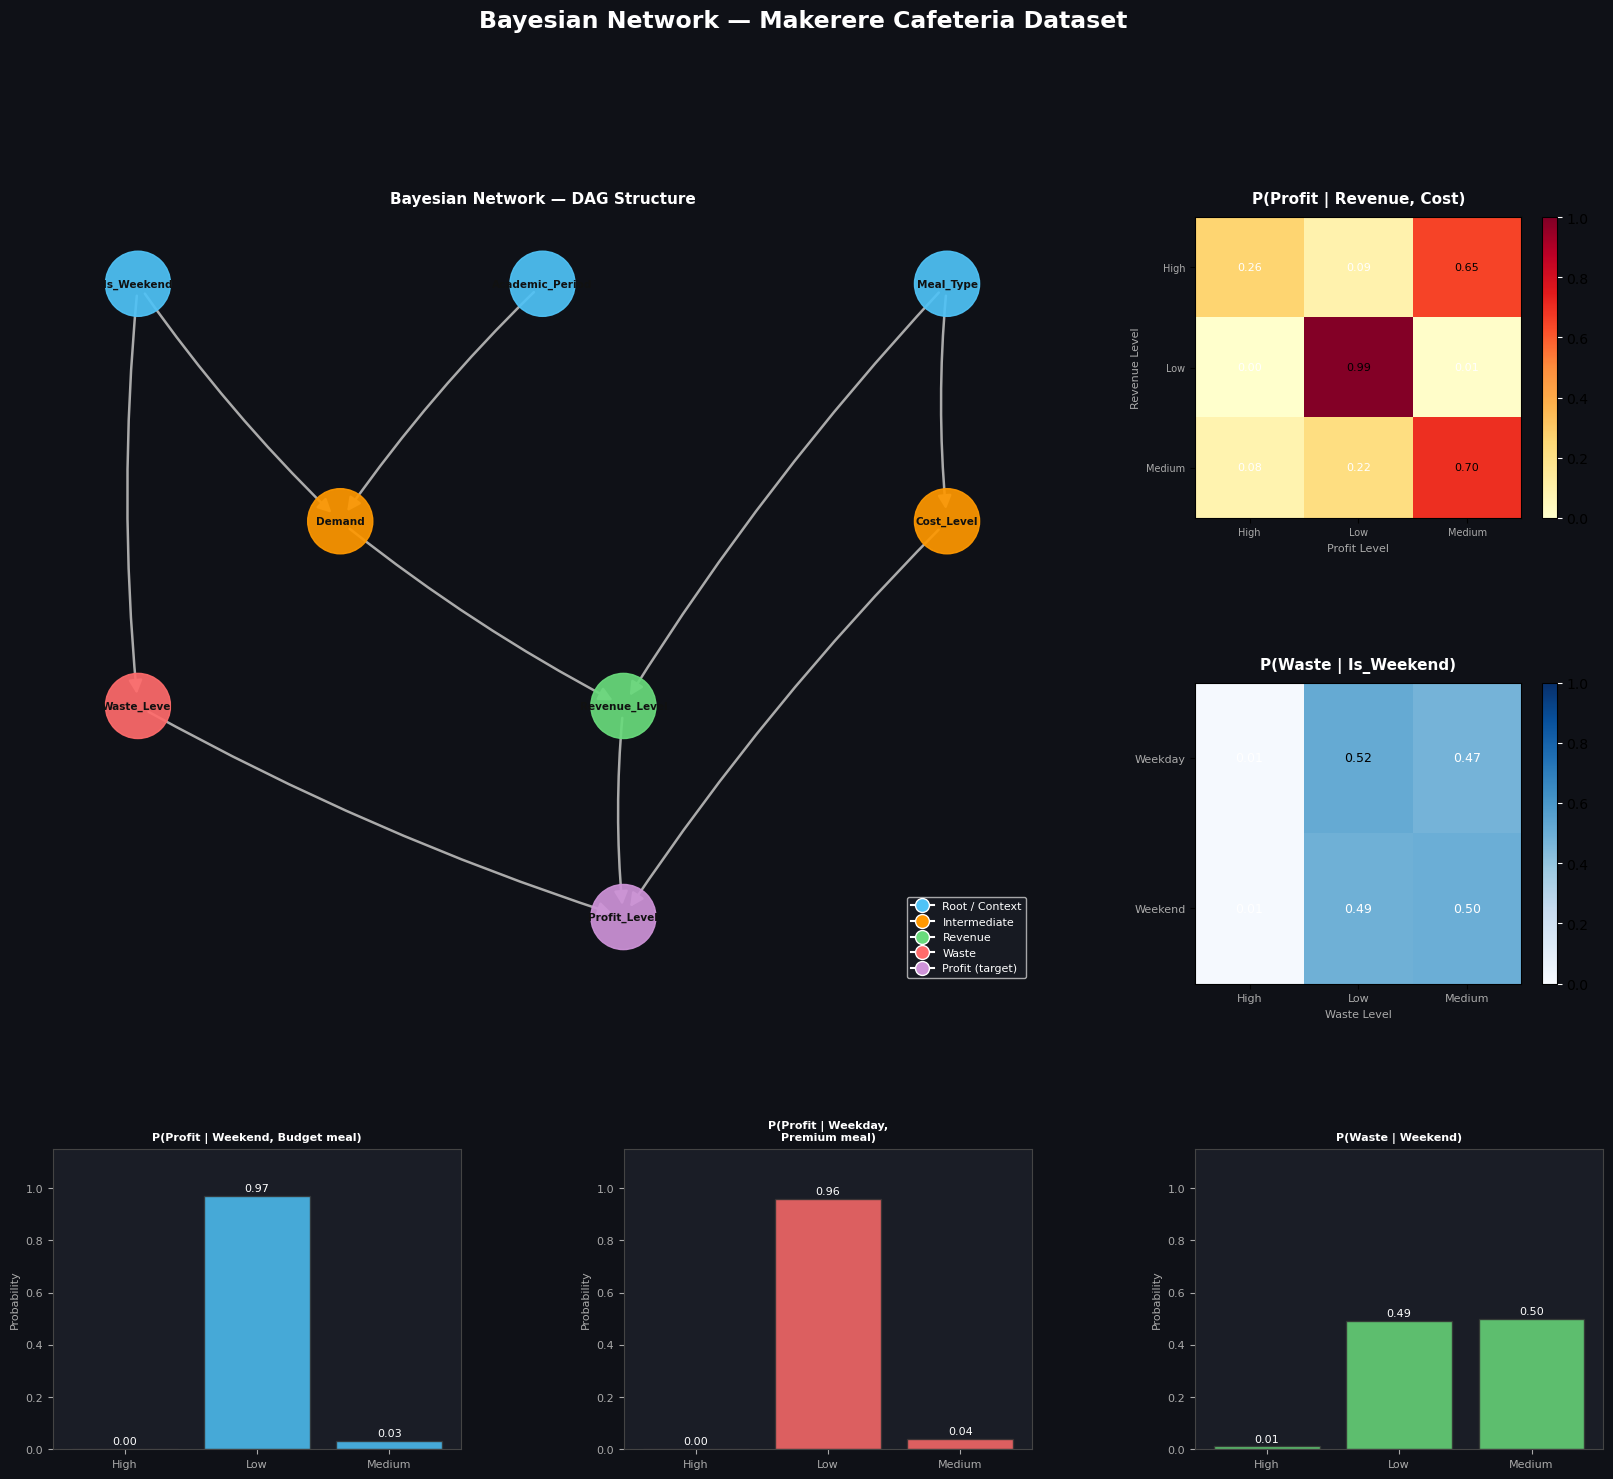

In [7]:
fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#0f1117')
gs = gridspec.GridSpec(3, 3, hspace=0.55, wspace=0.4)

tkw  = dict(color='white', fontsize=11, fontweight='bold', pad=10)
axkw = dict(color='#aaaaaa', fontsize=8)
sc   = '#1a1d26'

# ── Plot 1: DAG Structure ─────────────────────────────────
ax_dag = fig.add_subplot(gs[0:2, 0:2])
ax_dag.set_facecolor(sc)
ax_dag.set_title('Bayesian Network — DAG Structure', **tkw)

pos = {
    'Is_Weekend'     : (0.0, 1.0),
    'Academic_Period': (1.0, 1.0),
    'Meal_Type'      : (2.0, 1.0),
    'Demand'         : (0.5, 0.55),
    'Cost_Level'     : (2.0, 0.55),
    'Revenue_Level'  : (1.2, 0.2),
    'Waste_Level'    : (0.0, 0.2),
    'Profit_Level'   : (1.2, -0.2),
}

node_colors = {
    'Is_Weekend'     : '#4fc3f7',
    'Academic_Period': '#4fc3f7',
    'Meal_Type'      : '#4fc3f7',
    'Demand'         : '#ff9800',
    'Cost_Level'     : '#ff9800',
    'Revenue_Level'  : '#69db7c',
    'Waste_Level'    : '#ff6b6b',
    'Profit_Level'   : '#ce93d8',
}

nx.draw_networkx_nodes(G, pos, ax=ax_dag,
    node_color=[node_colors[n] for n in G.nodes()],
    node_size=2200, alpha=0.92)
nx.draw_networkx_labels(G, pos, ax=ax_dag,
    font_size=7.5, font_color='#111111', font_weight='bold')
nx.draw_networkx_edges(G, pos, ax=ax_dag,
    edge_color='#aaaaaa', arrows=True,
    arrowsize=20, width=1.8,
    connectionstyle='arc3,rad=0.05')

legend_items = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#4fc3f7', markersize=10, label='Root / Context'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#ff9800',  markersize=10, label='Intermediate'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#69db7c',  markersize=10, label='Revenue'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#ff6b6b',  markersize=10, label='Waste'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#ce93d8',  markersize=10, label='Profit (target)'),
]
ax_dag.legend(handles=legend_items, loc='lower right',
              facecolor=sc, labelcolor='white', fontsize=8, framealpha=0.8)
ax_dag.axis('off')

# ── Plot 2: CPT Heatmap — Profit_Level ───────────────────
ax_cpt = fig.add_subplot(gs[0, 2])
ax_cpt.set_facecolor(sc)
ax_cpt.set_title('P(Profit | Revenue, Cost)', **tkw)

profit_vals = valmap['Profit_Level']
# Build a revenue x profit table (marginalise over cost)
rev_vals = valmap['Revenue_Level']
hmap = np.zeros((len(rev_vals), len(profit_vals)))
for i, rv in enumerate(rev_vals):
    res = query({'Revenue_Level': rv}, 'Profit_Level', cpts, valmap, G, data)
    for j, pv in enumerate(profit_vals):
        hmap[i, j] = res.get(pv, 0)

im = ax_cpt.imshow(hmap, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax_cpt.set_xticks(range(len(profit_vals))); ax_cpt.set_xticklabels(profit_vals, color='#aaaaaa', fontsize=7)
ax_cpt.set_yticks(range(len(rev_vals)));   ax_cpt.set_yticklabels(rev_vals, color='#aaaaaa', fontsize=7)
ax_cpt.set_xlabel('Profit Level', **axkw); ax_cpt.set_ylabel('Revenue Level', **axkw)
for i in range(len(rev_vals)):
    for j in range(len(profit_vals)):
        ax_cpt.text(j, i, f'{hmap[i,j]:.2f}', ha='center', va='center',
                    color='black' if hmap[i,j] > 0.5 else 'white', fontsize=8)
plt.colorbar(im, ax=ax_cpt).ax.yaxis.set_tick_params(color='white')

# ── Plot 3: CPT — Waste by Weekend ───────────────────────
ax_w = fig.add_subplot(gs[1, 2])
ax_w.set_facecolor(sc)
ax_w.set_title('P(Waste | Is_Weekend)', **tkw)

waste_vals = valmap['Waste_Level']
wd_cats = ['Weekday', 'Weekend']
waste_hmap = np.zeros((2, len(waste_vals)))
for i, wd in enumerate(wd_cats):
    res = query({'Is_Weekend': wd}, 'Waste_Level', cpts, valmap, G, data)
    for j, wv in enumerate(waste_vals):
        waste_hmap[i, j] = res.get(wv, 0)

im2 = ax_w.imshow(waste_hmap, cmap='Blues', aspect='auto', vmin=0, vmax=1)
ax_w.set_xticks(range(len(waste_vals))); ax_w.set_xticklabels(waste_vals, color='#aaaaaa', fontsize=8)
ax_w.set_yticks(range(2)); ax_w.set_yticklabels(wd_cats, color='#aaaaaa', fontsize=8)
ax_w.set_xlabel('Waste Level', **axkw)
for i in range(2):
    for j in range(len(waste_vals)):
        ax_w.text(j, i, f'{waste_hmap[i,j]:.2f}', ha='center', va='center',
                  color='black' if waste_hmap[i,j] > 0.5 else 'white', fontsize=9)
plt.colorbar(im2, ax=ax_w).ax.yaxis.set_tick_params(color='white')

# ── Plot 4: Inference query bar charts ───────────────────
axes_q = [fig.add_subplot(gs[2, i]) for i in range(3)]
selected_queries = query_results[:3]

bar_palettes = ['#4fc3f7','#ff6b6b','#69db7c']
for ax_q, qr, color in zip(axes_q, selected_queries, bar_palettes):
    ax_q.set_facecolor(sc)
    result = qr['result']
    keys   = sorted(result.keys())
    vals   = [result[k] for k in keys]
    bars   = ax_q.bar(keys, vals, color=color, alpha=0.85, edgecolor='#333')
    for bar, v in zip(bars, vals):
        ax_q.text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.01, f'{v:.2f}',
                  ha='center', va='bottom', color='white', fontsize=8)
    # Wrap long titles
    title = qr['question']
    if len(title) > 32:
        mid = title.find(',', len(title)//2 - 5)
        title = title[:mid+1] + '\n' + title[mid+1:].strip() if mid != -1 else title
    ax_q.set_title(title, color='white', fontsize=8, fontweight='bold', pad=6)
    ax_q.set_ylabel('Probability', **axkw)
    ax_q.set_ylim(0, 1.15)
    for sp in ax_q.spines.values(): sp.set_color('#444')
    ax_q.tick_params(colors='#aaaaaa', labelsize=8)

fig.suptitle('Bayesian Network — Makerere Cafeteria Dataset',
             color='white', fontsize=17, fontweight='bold', y=1.01)

# plt.savefig('bayesian_network_cafeteria.png',
#             dpi=140, bbox_inches='tight', facecolor=fig.get_facecolor())
# plt.close()
# print("\n✅ Plot saved!")
